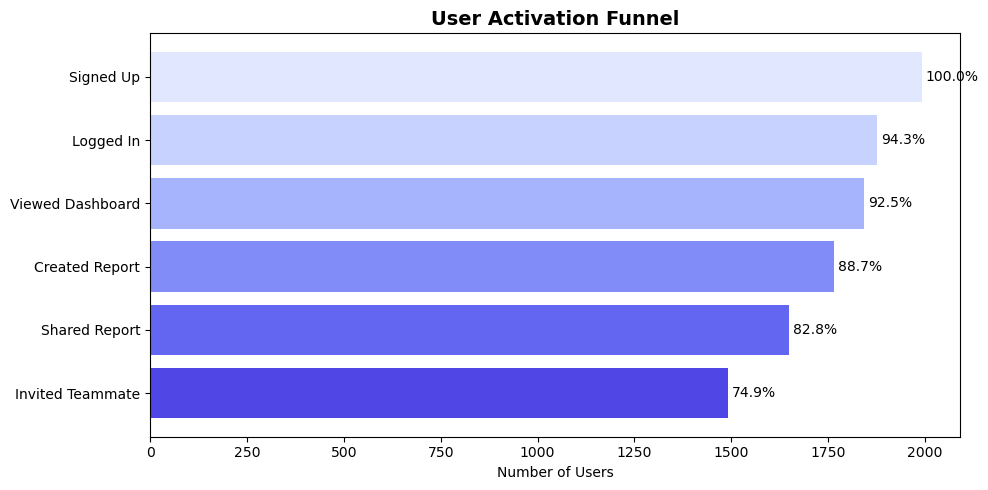

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\data\saas_events.csv', parse_dates=['event_date', 'signup_date'])

# Define activation = user did report_create within 7 days of signup
df['days_since_signup'] = (df['event_date'] - df['signup_date']).dt.days

all_users       = df['user_id'].nunique()
logged_in       = df[df['event_name']=='login']['user_id'].nunique()
viewed_dashboard= df[df['event_name']=='dashboard_view']['user_id'].nunique()
created_report  = df[df['event_name']=='report_create']['user_id'].nunique()
shared_report   = df[df['event_name']=='report_share']['user_id'].nunique()
invited_team    = df[df['event_name']=='invite_teammate']['user_id'].nunique()

funnel_stages = ['Signed Up', 'Logged In', 'Viewed Dashboard',
                 'Created Report', 'Shared Report', 'Invited Teammate']
funnel_values = [all_users, logged_in, viewed_dashboard,
                 created_report, shared_report, invited_team]

conv_rates = [f"{v/all_users*100:.1f}%" for v in funnel_values]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4F46E5','#6366F1','#818CF8','#A5B4FC','#C7D2FE','#E0E7FF']
bars = ax.barh(funnel_stages[::-1], funnel_values[::-1], color=colors)

for bar, rate in zip(bars, conv_rates[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            rate, va='center', fontsize=10)

ax.set_title('User Activation Funnel', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Users')
plt.tight_layout()
plt.savefig(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\images\funnel_analysis.png', dpi=150)
plt.show()